# 토큰화: BPE와 SentencePiece - BPE 토큰화 알고리즘

- Tutorial ID: `adv-9-1`
- Tutorial: 토큰화: BPE와 SentencePiece
- Section ID: `adv-9-1-1`
- Section: BPE 토큰화 알고리즘

> 이 노트북은 GPT-2, LLaMA 같은 언어 모델이 실제로 사용하는 토큰화 방식인 **BPE(Byte Pair Encoding)** 를
> 라이브러리 없이 직접 구현하면서, "자주 등장하는 글자 쌍을 찾아 합친다"는 단순한 규칙이 어떻게
> 하나의 어휘집(vocabulary)을 만들어내는지 한 단계씩 눈으로 확인하는 실습입니다.
> 코드를 먼저 훑어보지 말고, 위에서부터 순서대로 셀을 실행하면서 따라와 주세요.

In [1]:
# ============================================================
# 코드 읽는 법 — BPE 토큰화 알고리즘
#
# 이 노트북은 "실행 한 번으로 끝"이 아니라,
#   단어 → 글자 단위로 쪼개기 → 자주 붙어 다니는 두 조각을 하나로 합치기
# 를 반복하면서, 그 조각들이 점점 더 큰 단위로 자라나는 과정을
# 한 단계(step)씩 직접 눈으로 추적하기 위한 실습 노트입니다.
#
# 학습 목표:
#   1) 글자 단위로 쪼개진 단어가 병합(merge)을 거듭하며
#      어떻게 점점 더 큰 서브워드 단위로 뭉쳐지는지 직접 확인한다.
#   2) "가장 자주 등장하는 인접 쌍을 찾아 합친다"는 규칙이
#      코드의 어느 부분에 해당하는지 정확히 짚어낸다.
#   3) 학습된 병합 규칙을, 학습 때 보지 못한 새 단어에도 적용해 보면서
#      BPE가 왜 미등록 단어(OOV) 문제를 줄여주는지 직접 확인한다.
#   4) 어휘 크기(vocab size)가 커질수록 시퀀스 길이는 짧아진다는
#      트레이드오프를, 우리가 만든 작은 코퍼스로 직접 측정해본다.
#
# 읽는 순서:
#   1) "0. 시작하기 전에" 마크다운에서 토큰화가 왜 필요한지부터 읽습니다.
#   2) get_pair_counts / merge_pair 두 함수가 각각
#      "쌍의 빈도를 센다" / "가장 빈번한 쌍을 하나로 합친다"는 역할을
#      코드로 어떻게 구현하는지 작은 예시로 먼저 확인합니다.
#   3) 실제 코퍼스(corpus)에 두 함수를 반복 적용하면서,
#      매 단계 어떤 쌍이 선택되고 단어들이 어떻게 바뀌는지 출력으로 확인합니다.
#   4) 그래프로 어휘 크기 ↑ / 시퀀스 길이 ↓ 트레이드오프를 다시 확인합니다.
#   5) 코퍼스에 없던 새 단어를 직접 넣어보면서 일반화를 확인합니다.
#
# 실험해보면 좋은 것들:
#   - corpus 리스트의 단어나 등장 횟수를 바꾸면 어떤 쌍이 먼저 합쳐질까요?
#   - 병합 횟수(N_MERGES)를 줄이거나 늘리면 결과가 어떻게 달라질까요?
#   - tokenize_word 함수에 자신만의 단어를 넣어보면 어떻게 쪼개질까요?
#
# 주의:
#   - 병합 "결과"를 외우기보다, 같은 쌍이 왜 반복해서 뽑히는지,
#     그 쌍이 합쳐진 뒤 다음 단계에서 무엇이 달라지는지를 보세요.
#   - 이 노트북은 numpy/matplotlib만 사용하는 순수 "직접 구현" 버전이라
#     별도 설치 없이 Colab이나 로컬 어디서든 바로 실행됩니다.
#   - 실제 GPT-2 등은 동일한 원리를 훨씬 큰 코퍼스(수십~수백 GB 텍스트)에
#     적용해 수만 번의 병합을 학습합니다. 원리는 똑같고, 규모만 다릅니다.

## 0. 시작하기 전에: 토큰화(Tokenization)가 왜 필요할까요?

언어 모델은 사실 "글자"를 이해하지 못합니다. 모델 내부는 전부 **숫자 연산**이기 때문에,
"low" 같은 문자열을 모델에 넣으려면 먼저 **숫자(정수 ID)의 나열**로 바꿔야 합니다. 이렇게
텍스트를 모델이 다룰 수 있는 단위(토큰, token)로 쪼개고 각 토큰에 ID를 부여하는 과정을
**토큰화(Tokenization)** 라고 부릅니다.

토큰화 방법에는 여러 가지가 있는데, 먼저 두 가지 극단적인 방법을 살펴보면서 왜 BPE 같은
"중간 지점" 방식이 필요한지 알아보겠습니다.

**방법 1. 단어 단위(Word-level) 토큰화** — 공백을 기준으로 단어를 통째로 토큰 하나로 사용합니다.

```
"I love running" → ["I", "love", "running"]
```

토큰 하나하나의 의미가 사람 눈에 명확하다는 장점이 있지만, 두 가지 문제가 있습니다.
첫째, "run", "runs", "running", "ran"은 의미상 한 가족인데도 전부 별개의 토큰으로 어휘집에
따로 등록해야 해서 **어휘집이 매우 커집니다.** 둘째, 학습 데이터에 없던 새 단어(신조어,
오타, 외래어 등)가 나오면 표현할 방법이 없어 `<UNK>`(unknown) 토큰으로 뭉뚱그려지고
의미 정보가 사실상 사라집니다. 이를 **OOV(Out-Of-Vocabulary, 미등록 단어) 문제**라고 합니다.

**방법 2. 글자 단위(Character-level) 토큰화** — 모든 텍스트를 알파벳 하나하나로 쪼갭니다.

```
"I love running" → ["I", " ", "l", "o", "v", "e", " ", "r", "u", "n", "n", "i", "n", "g"]
```

알파벳 개수만큼만 어휘집이 있으면 되니 어휘집이 아주 작고, 모르는 단어가 나와도 글자
단위로는 항상 표현되므로 OOV 문제가 사라집니다. 그런데 이번엔 문장이 토큰 단위로 보면
**매우 길어집니다.** 트랜스포머의 셀프어텐션 연산량은 시퀀스 길이의 제곱에 비례해서
늘어나기 때문에, 시퀀스가 길어질수록 계산 비용이 빠르게 증가하고 멀리 떨어진 글자들
사이의 관계를 학습하기도 더 어려워집니다.

**방법 3. 서브워드 단위(Subword-level) 토큰화** — 단어 단위와 글자 단위의 중간 지점을
찾는 방법입니다. 자주 등장하는 단어는 통째로 하나의 토큰으로 유지하고, 드물게 등장하는
단어만 의미 있는 조각(서브워드)으로 쪼갭니다.

```
"running"     → ["run", "ning"]            # 자주 쓰이는 어간 + 어미로 분리
"unhappiness" → ["un", "happi", "ness"]    # 접두사 + 어근 + 접미사로 분리
```

자주 나오는 단어는 그대로 1개 토큰이라 시퀀스가 너무 길어지지 않고, 드문 단어나 처음
보는 단어도 알고 있는 더 작은 조각들의 조합으로 표현할 수 있어 OOV 문제가 크게 줄어듭니다.
결과적으로 **어휘집 크기와 시퀀스 길이 사이의 균형**을 맞출 수 있는 것이죠.

**BPE(Byte Pair Encoding)** 는 이 "자주 붙어 다니는 조각을 자동으로 찾아 합쳐 나가는" 규칙을
구현하는 대표적인 알고리즘입니다. 원래 1994년 Philip Gage가 제안한 데이터 압축 알고리즘이었는데,
2015년 Sennrich 등이 발표한 논문(*Neural Machine Translation of Rare Words with Subword Units*)에서
자연어처리용 토큰화 기법으로 변형되어 사용되기 시작했고, 지금은 GPT 계열을 비롯한 수많은
모델이 이 방식(혹은 변형)을 사용합니다. 아래에서 이 알고리즘을 직접 코드로 구현해 보겠습니다.

In [2]:
# 이 노트북에서 사용할 라이브러리를 불러옵니다.
#   - numpy: 어휘 크기처럼 단순한 수치를 다룰 때 사용 (필수는 아니지만 관례적으로 함께 불러옵니다)
#   - collections.Counter: 코퍼스에 단어가 몇 번씩 등장하는지 셀 때 사용 (그냥 dict보다 편리합니다)
import numpy as np
from collections import Counter

print("=" * 60)
print("BPE (Byte-Pair Encoding) 토큰화")
print("=" * 60)

BPE (Byte-Pair Encoding) 토큰화

## 1. BPE 알고리즘 직접 구현하기

### 네 단계로 요약하면

BPE는 다음 네 단계를 정해진 횟수만큼(또는 목표 어휘 크기에 도달할 때까지) 반복하는
알고리즘입니다.

1. **초기화** — 코퍼스(corpus, 학습에 쓸 예문 모음)의 모든 단어를 **글자 단위**로 쪼개고,
   단어 끝에 특수 기호 `</w>`를 붙입니다.
   → 왜 끝 표시가 필요할까요? `</w>`가 없으면 한 단어의 끝부분 글자와 바로 다음 단어의
   시작 글자가 마치 같은 단어 안에 있는 것처럼 잘못 합쳐질 수 있습니다. `</w>`는
   "여기서 한 단어가 끝났다"는 표시를 남겨서 이런 실수를 막아줍니다.

2. **빈도 계산** — 현재 토큰들에서 **서로 붙어 있는(인접한) 두 토큰의 쌍**이 코퍼스
   전체에서 몇 번 등장하는지 모두 셉니다.

3. **병합(merge)** — 가장 빈도가 높은 쌍 하나를 골라 둘을 합쳐 **새로운 토큰 1개**로
   만들고, 어휘집(vocabulary)에 추가합니다.

4. **반복** — 2~3단계를 원하는 횟수만큼 반복합니다. 반복할수록 자주 붙어 다니는 글자
   조합들이 점점 더 큰 덩어리(서브워드)로 뭉쳐집니다.

### 코드를 실행하기 전에, 손으로 1단계만 먼저 풀어봅시다

아래에서 실제로 사용할 코퍼스는 `"low"`가 3번, `"lower"`가 2번, `"newest"`와 `"widest"`가
각 1번 등장합니다. 이 단어들을 글자 단위로 쪼개면:

| 단어 | 글자 단위 분해 | 코퍼스 내 등장 횟수 |
|---|---|---|
| low | l, o, w, `</w>` | 3 |
| lower | l, o, w, e, r, `</w>` | 2 |
| newest | n, e, w, e, s, t, `</w>` | 1 |
| widest | w, i, d, e, s, t, `</w>` | 1 |

등장 횟수까지 고려해서 인접한 쌍의 빈도를 모두 세어보면 (예: "low"가 3번 등장하니
그 안의 모든 쌍 (l,o), (o,w), (w,`</w>`)도 3번씩 더해집니다):

| 쌍 | 등장 횟수 | 어디서 나왔나 |
|---|---|---|
| **(l, o)** | **5** | low×3 + lower×2 |
| **(o, w)** | **5** | low×3 + lower×2 |
| (w, `</w>`) | 3 | low×3 |
| (w, e) | 3 | lower×2 + newest×1 |
| (e, r) | 2 | lower×2 |
| (e, s) | 2 | newest×1 + widest×1 |
| (s, t) | 2 | newest×1 + widest×1 |
| (t, `</w>`) | 2 | newest×1 + widest×1 |
| (n,e), (e,w), (w,i), (i,d), (d,e) | 각 1 | newest 또는 widest |

가장 큰 값은 5이고, `(l, o)`와 `(o, w)`가 공동 1위로 동점입니다! 이런 동점 상황에서
코드의 `max()` 함수는 **가장 먼저 발견된 쌍**을 선택합니다. 코퍼스를 앞에서부터 훑으면
"low"의 (l, o)가 (o, w)보다 먼저 등장하므로, 이번에는 `(l, o)`가 선택될 것이라고
예측할 수 있습니다. 잠시 후 코드 실행 결과로 이 예측이 맞는지 직접 확인해 봅시다.

In [3]:
def get_pair_counts(tokens_list):
    """
    여러 단어의 토큰 리스트를 받아서, '서로 붙어 있는 두 토큰(쌍)'이
    전체 코퍼스에서 몇 번 등장하는지 세어 딕셔너리로 돌려줍니다.

    예) tokens_list = [['l','o','w','</w>']] 라면
        인접한 쌍은 ('l','o'), ('o','w'), ('w','</w>') 세 개이고,
        각각 1번씩 등장했으니 {('l','o'):1, ('o','w'):1, ('w','</w>'):1} 을 반환합니다.
    """
    counts = {}
    for tokens in tokens_list:                    # 코퍼스에 있는 단어를 한 개씩 꺼내서
        for i in range(len(tokens) - 1):           # 그 단어 안에서 인접한 자리를 차례로 보면서
            pair = (tokens[i], tokens[i + 1])      # (현재 토큰, 바로 다음 토큰) 쌍을 만들고
            counts[pair] = counts.get(pair, 0) + 1 # 그 쌍의 등장 횟수를 1 늘립니다
            # counts.get(pair, 0): pair가 아직 딕셔너리에 없으면 0을, 있으면 기존 값을 반환
    return counts


def merge_pair(tokens_list, pair, new_token):
    """
    tokens_list 안에서 특정 쌍(pair)이 인접해 등장할 때마다
    그 둘을 new_token 하나로 합칩니다.

    예) tokens_list = [['l','o','w','</w>']], pair=('l','o'), new_token='lo' 라면
        결과는 [['lo','w','</w>']] 가 됩니다. ('l'과 'o' 두 글자가 'lo' 한 토큰으로 합쳐짐)
    """
    result = []
    for tokens in tokens_list:                # 단어를 한 개씩 꺼내서
        new_tokens = []
        i = 0
        while i < len(tokens):
            # 지금 위치(i)와 바로 다음 위치(i+1)의 토큰이 합치려는 쌍과 정확히 일치하면
            if i < len(tokens) - 1 and tokens[i] == pair[0] and tokens[i + 1] == pair[1]:
                new_tokens.append(new_token)    # 두 토큰 대신, 합쳐진 새 토큰 1개를 넣고
                i += 2                          # 두 칸을 건너뜁니다 (이미 둘 다 처리했으므로)
            else:
                new_tokens.append(tokens[i])    # 합칠 대상이 아니면 그대로 한 칸만 이동
                i += 1
        result.append(new_tokens)
    return result


# ---------------------------------------------------------------
# 본격적으로 적용하기 전에, 손바닥만 한 예시로 두 함수가 의도대로
# 동작하는지 먼저 확인해 봅니다. (바로 위 마크다운에서 손으로 풀어본
# "low"x2 + "lower"x1 예시를 그대로 코드로 옮긴 것입니다)
# ---------------------------------------------------------------
mini_example = [
    ['l', 'o', 'w', '</w>'],
    ['l', 'o', 'w', '</w>'],
    ['l', 'o', 'w', 'e', 'r', '</w>'],
]
print("미니 예시:", mini_example)

mini_counts = get_pair_counts(mini_example)
print("\n[get_pair_counts 결과] 쌍 : 빈도")
for pair, cnt in mini_counts.items():
    print(f"  {pair} : {cnt}")

mini_merged = merge_pair(mini_example, ('l', 'o'), 'lo')
print("\n[merge_pair 결과] ('l','o') -> 'lo' 로 합친 뒤:")
for before, after in zip(mini_example, mini_merged):
    print(f"  {before}  ->  {after}")

미니 예시: [['l', 'o', 'w', '</w>'], ['l', 'o', 'w', '</w>'], ['l', 'o', 'w', 'e', 'r', '</w>']]

[get_pair_counts 결과] 쌍 : 빈도
  ('l', 'o') : 3
  ('o', 'w') : 3
  ('w', '</w>') : 2
  ('w', 'e') : 1
  ('e', 'r') : 1
  ('r', '</w>') : 1

[merge_pair 결과] ('l','o') -> 'lo' 로 합친 뒤:
  ['l', 'o', 'w', '</w>']  ->  ['lo', 'w', '</w>']
  ['l', 'o', 'w', '</w>']  ->  ['lo', 'w', '</w>']
  ['l', 'o', 'w', 'e', 'r', '</w>']  ->  ['lo', 'w', 'e', 'r', '</w>']

함수 두 개가 작은 예시에서 정확히 의도대로 동작하는 것을 확인했습니다. 이제 더 다양한
단어가 섞인 실제 코퍼스에 적용해서, 병합이 반복될수록 무슨 일이 일어나는지 끝까지
따라가 보겠습니다.

In [4]:
# 코퍼스(corpus): BPE를 학습시킬 예문 모음입니다.
# 일부러 어간이 같은 단어들을 섞어 두어서("low"/"lower", "newest"/"widest")
# 병합이 진행될수록 공통된 글자 조각이 어떻게 하나의 토큰으로 뭉쳐지는지 보기 좋게 만들었습니다.
corpus = ["low", "lower", "newest", "widest", "low", "low", "lower"]
print("코퍼스:", corpus)
print("단어별 등장 횟수:", dict(Counter(corpus)))

# 각 단어를 글자 단위로 쪼개고, 단어 끝에 </w> 표시를 붙입니다.
#   "low" -> ['l', 'o', 'w', '</w>']
# [c for c in word] 는 문자열을 한 글자씩 분리한 리스트로 만듭니다 (list(word)와 같은 결과).
tokens_list = [[c for c in word] + ['</w>'] for word in corpus]

print(f"\n예) '{corpus[0]}' 의 초기 토큰 분해 결과: {tokens_list[0]}")
print(f"예) '{corpus[1]}' 의 초기 토큰 분해 결과: {tokens_list[1]}")

# 초기 어휘집 = 코퍼스에 등장하는 모든 글자(+ </w>)의 모음
vocab = set()
for tokens in tokens_list:
    vocab.update(tokens)

print(f"\n초기 어휘 크기: {len(vocab)}개")
print(f"초기 어휘: {sorted(vocab)}")

코퍼스: ['low', 'lower', 'newest', 'widest', 'low', 'low', 'lower']
단어별 등장 횟수: {'low': 3, 'lower': 2, 'newest': 1, 'widest': 1}

예) 'low' 의 초기 토큰 분해 결과: ['l', 'o', 'w', '</w>']
예) 'lower' 의 초기 토큰 분해 결과: ['l', 'o', 'w', 'e', 'r', '</w>']

초기 어휘 크기: 11개
초기 어휘: ['</w>', 'd', 'e', 'i', 'l', 'n', 'o', 'r', 's', 't', 'w']

In [5]:
# ============================================================
# BPE 반복 학습
#
# 아래 반복문은 앞서 손으로 풀어본 "빈도 계산 -> 가장 빈번한 쌍 병합"을
# 컴퓨터가 자동으로, 그것도 아주 빠르게 반복하는 것뿐입니다.
# 매 단계(step)마다 무슨 일이 일어났는지 전부 출력해서 보여줍니다.
# ============================================================

N_MERGES = 20     # 병합을 최대 몇 번 시도할지 (코퍼스가 작아서 도중에 자동으로 멈출 수 있습니다)
TOP_K_PRINT = 5   # 매 단계, 경쟁한 후보 쌍을 상위 몇 개까지 보여줄지

# 화면에 변화를 보여줄 대표 단어 4개 (코퍼스에 등장하는 '서로 다른' 단어 전부)
sample_words = ["low", "lower", "newest", "widest"]
sample_first_idx = [corpus.index(w) for w in sample_words]  # 각 단어가 corpus에서 처음 나오는 위치

merges = []                                   # 학습된 병합 규칙을 "학습된 순서대로" 저장
                                               # -> 이 순서가 곧 실전 인코딩에서의 '우선순위'가 됩니다 (뒤에서 사용)
vocab_size_history = [len(vocab)]             # 매 단계의 어휘 크기 기록 (그래프용)
total_tokens_history = [sum(len(t) for t in tokens_list)]  # 매 단계의 코퍼스 전체 토큰 개수 기록 (그래프용)

for step in range(N_MERGES):
    pair_counts = get_pair_counts(tokens_list)

    if not pair_counts:
        print(f"\n{'='*60}")
        print("[종료] 더 이상 합칠 수 있는 쌍이 없습니다 (모든 단어가 한 토큰으로 합쳐졌습니다)")
        print(f"{'='*60}")
        break

    # 빈도가 높은 순서로 후보 쌍들을 정렬합니다.
    # (참고: 1등만 필요하면 max(pair_counts, key=pair_counts.get) 한 줄로도 충분합니다.
    #  여기서는 후보들이 얼마나 경쟁했는지 보여주려고 전체를 정렬합니다.)
    ranked = sorted(pair_counts.items(), key=lambda kv: kv[1], reverse=True)
    best_pair, best_freq = ranked[0]
    new_token = best_pair[0] + best_pair[1]

    print(f"\n{'='*60}")
    print(f"[Step {step + 1}] 가장 빈번한 쌍 찾기")
    print(f"{'='*60}")
    print(f"  상위 {min(TOP_K_PRINT, len(ranked))}개 후보:")
    for rank, (pair, freq) in enumerate(ranked[:TOP_K_PRINT]):
        marker = "  <- 선택!" if rank == 0 else ""
        tie_note = " (동점, 먼저 발견된 쪽이 선택됨)" if freq == best_freq and rank != 0 else ""
        print(f"    {str(pair):20s} -> {freq}회{marker}{tie_note}")

    merges.append((best_pair, new_token))
    tokens_list = merge_pair(tokens_list, best_pair, new_token)
    vocab.add(new_token)
    vocab_size_history.append(len(vocab))
    total_tokens_history.append(sum(len(t) for t in tokens_list))

    print(f"\n  병합 규칙 #{len(merges)}: '{best_pair[0]}' + '{best_pair[1]}' -> '{new_token}'")
    print(f"  (어휘집에 '{new_token}' 추가 -> 현재 어휘 크기: {len(vocab)}개, 전체 토큰 개수: {total_tokens_history[-1]}개)")

    print("\n  대표 단어 4개의 변화:")
    for w, idx in zip(sample_words, sample_first_idx):
        print(f"    {w:<8} -> {tokens_list[idx]}")

print(f"\n{'='*60}")
print(f"최종 어휘 (총 {len(vocab)}개):")
print(f"{'='*60}")
print(sorted(vocab))

[Step 1] 가장 빈번한 쌍 찾기
  상위 5개 후보:
    ('l', 'o')           -> 5회  <- 선택!
    ('o', 'w')           -> 5회 (동점, 먼저 발견된 쪽이 선택됨)
    ('w', '</w>')        -> 3회
    ('w', 'e')           -> 3회
    ('e', 'r')           -> 2회

  병합 규칙 #1: 'l' + 'o' -> 'lo'
  (어휘집에 'lo' 추가 -> 현재 어휘 크기: 12개, 전체 토큰 개수: 33개)

  대표 단어 4개의 변화:
    low      -> ['lo', 'w', '</w>']
    lower    -> ['lo', 'w', 'e', 'r', '</w>']
    newest   -> ['n', 'e', 'w', 'e', 's', 't', '</w>']
    widest   -> ['w', 'i', 'd', 'e', 's', 't', '</w>']

[Step 2] 가장 빈번한 쌍 찾기
  상위 5개 후보:
    ('lo', 'w')          -> 5회  <- 선택!
    ('w', '</w>')        -> 3회
    ('w', 'e')           -> 3회
    ('e', 'r')           -> 2회
    ('r', '</w>')        -> 2회

  병합 규칙 #2: 'lo' + 'w' -> 'low'
  (어휘집에 'low' 추가 -> 현재 어휘 크기: 13개, 전체 토큰 개수: 28개)

  대표 단어 4개의 변화:
    low      -> ['low', '</w>']
    lower    -> ['low', 'e', 'r', '</w>']
    newest   -> ['n', 'e', 'w', 'e', 's', 't', '</w>']
    widest   -> ['w', 'i', 'd', 'e', 's', 't', '</w>']

[Step 3] 가장 빈

### 병합 과정을 그래프로 다시 확인하기

출력 결과를 보면 병합이 반복될수록 **어휘 크기는 점점 커지고, 코퍼스 전체의 토큰
개수(= 시퀀스 길이의 총합)는 점점 줄어드는** 것을 알 수 있습니다. 이것이 바로 "0. 시작하기
전에"에서 이야기한 "어휘 크기와 시퀀스 길이는 트레이드오프 관계에 있다"는 말의 실제
모습입니다. 숫자로 확인했으니, 이번엔 그래프로 한눈에 살펴보겠습니다.

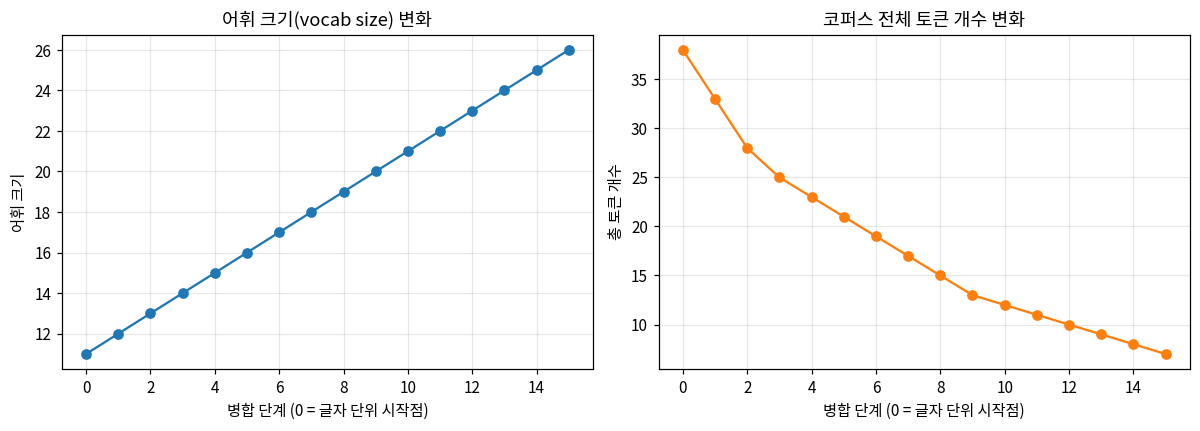

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 그래프에 한글이 깨지지 않고 보이도록 폰트를 설정합니다.
# (아래 경로들에 해당하는 폰트가 없는 환경이라면 이 부분은 자동으로 건너뛰고
#  영문 기본 폰트로 표시됩니다 -- 그래프의 숫자나 추세를 이해하는 데는 지장이 없습니다)
_KOREAN_FONT_CANDIDATES = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",   # Linux / Colab
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",       # macOS
    "C:/Windows/Fonts/malgun.ttf",                               # Windows
]
for _font_path in _KOREAN_FONT_CANDIDATES:
    if os.path.exists(_font_path):
        fm.fontManager.addfont(_font_path)
        plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 기호가 깨지는 것 방지

steps = list(range(len(vocab_size_history)))  # 0(초기 글자 단위) ~ 마지막 병합 단계

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(steps, vocab_size_history, marker="o", color="tab:blue")
axes[0].set_title("어휘 크기(vocab size) 변화")
axes[0].set_xlabel("병합 단계 (0 = 글자 단위 시작점)")
axes[0].set_ylabel("어휘 크기")
axes[0].grid(alpha=0.3)

axes[1].plot(steps, total_tokens_history, marker="o", color="tab:orange")
axes[1].set_title("코퍼스 전체 토큰 개수 변화")
axes[1].set_xlabel("병합 단계 (0 = 글자 단위 시작점)")
axes[1].set_ylabel("총 토큰 개수")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

왼쪽 그래프는 계속 올라가고, 오른쪽 그래프는 계속 내려갑니다. 이번 실습에서는 병합을
거듭하며 **어휘 크기가 11개 → 26개(약 2.4배)** 로 늘어나는 동안, **코퍼스 전체 토큰
개수는 38개 → 7개(약 5.4배)** 로 줄었습니다. "어휘를 늘리는 대신 시퀀스를 줄인다"는
BPE의 트레이드오프가 바로 이 모양입니다.

### 학습 데이터에 없던 새 단어는 어떻게 토큰화될까요?

지금까지는 이미 "학습"이 끝난 뒤의 결과(최종 어휘, 병합 단계별 변화)를 살펴봤습니다.
그런데 실전에서는 학습이 끝난 뒤 **한 번도 본 적 없는 새로운 단어**를 토큰화해야 합니다.
이때 BPE는 어떻게 동작할까요?

방법은 단순합니다 — 학습 과정에서 익힌 병합 규칙들을 **학습된 순서 그대로** 새 단어에도
차례차례 적용하면 됩니다. 즉, 앞선 반복문에서 `merges` 리스트에 저장해 둔
`[(쌍1, 합친토큰1), (쌍2, 합친토큰2), ...]` 순서가 그대로 "이 쌍을 먼저 합치고, 그다음
이 쌍을 합치고…" 하는 **우선순위**가 되는 것입니다.

이렇게 하면 학습 코퍼스에 단 한 번도 등장하지 않았던 단어라도, 학습 때 본 적 있는
글자 조각들의 조합으로 표현할 수 있습니다 — 이것이 바로 BPE가 OOV(미등록 단어) 문제를
줄여주는 원리입니다. 코드로 직접 확인해 봅시다.

In [7]:
def tokenize_word(word, merges):
    """
    학습 단계에서 만든 병합 규칙(merges)을 '학습된 순서 그대로' 적용해서
    새 단어를 토큰화합니다. 이것이 바로 BPE의 실전 인코딩 절차입니다.
    """
    tokens = list(word) + ['</w>']     # 1) 일단 글자 단위로 쪼개고 끝 표시를 붙입니다 (학습 때와 동일)
    for pair, new_token in merges:     # 2) 학습된 규칙을 '학습된 순서대로' 하나씩 시도합니다
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and tokens[i] == pair[0] and tokens[i + 1] == pair[1]:
                new_tokens.append(new_token)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        tokens = new_tokens
        # 주의: 규칙은 한 번 정해진 순서대로만 적용됩니다.
        # 즉 merges 리스트 앞쪽(=학습 단계에서 더 일찍 익힌 규칙)이 먼저 적용되고,
        # 그 결과로 이미 합쳐져 버린 글자는 뒤쪽 규칙이 더 이상 건드릴 수 없습니다.
    return tokens


print("학습 코퍼스에는 없었던 새로운 단어들을 토큰화해 봅니다:")
print("-" * 60)
test_words = ["lowering", "newer", "wider", "lowest", "slowest"]
for w in test_words:
    print(f"  '{w}'  ->  {tokenize_word(w, merges)}")

print("\n관찰 포인트")
print("-" * 60)
print("""\
* 'lowering' -> ['lower', 'i', 'n', 'g', '</w>']
  학습 때 완성된 단어 'lower'를 통째로 재사용하고, 한 번도 본 적 없는
  '-ing' 부분만 글자 단위로 남았습니다. 모르는 부분이 있어도 <UNK> 없이
  표현할 수 있다는 것이 핵심입니다.

* 'lowest' -> ['lowe', 's', 't', '</w>']
  사람이 보기엔 'low' + 'est'로 쪼개지는 게 더 자연스러워 보일 수 있지만,
  실제로는 'lowe' + 's' + 't' 가 되었습니다. 학습 단계에서 ('low','e') 규칙이
  ('e','s') 규칙보다 먼저(우선순위가 높게) 학습되었기 때문에, 'lowest'의 'e'는
  ('e','s')가 적용되기도 전에 이미 'low'와 합쳐져 'lowe'가 되어버린 것입니다.
  -> BPE는 "사람이 보기에 자연스러운 형태소"가 아니라, 학습 코퍼스에서
     통계적으로 먼저/자주 합쳐진 순서를 그대로 따른다는 것을 보여주는 예시입니다.
""")

학습 코퍼스에는 없었던 새로운 단어들을 토큰화해 봅니다:
------------------------------------------------------------
  'lowering'  ->  ['lower', 'i', 'n', 'g', '</w>']
  'newer'  ->  ['new', 'e', 'r', '</w>']
  'wider'  ->  ['wid', 'e', 'r', '</w>']
  'lowest'  ->  ['lowe', 's', 't', '</w>']
  'slowest'  ->  ['s', 'lowe', 's', 't', '</w>']

관찰 포인트
------------------------------------------------------------
* 'lowering' -> ['lower', 'i', 'n', 'g', '</w>']
  학습 때 완성된 단어 'lower'를 통째로 재사용하고, 한 번도 본 적 없는
  '-ing' 부분만 글자 단위로 남았습니다. 모르는 부분이 있어도 <UNK> 없이
  표현할 수 있다는 것이 핵심입니다.

* 'lowest' -> ['lowe', 's', 't', '</w>']
  사람이 보기엔 'low' + 'est'로 쪼개지는 게 더 자연스러워 보일 수 있지만,
  실제로는 'lowe' + 's' + 't' 가 되었습니다. 학습 단계에서 ('low','e') 규칙이
  ('e','s') 규칙보다 먼저(우선순위가 높게) 학습되었기 때문에, 'lowest'의 'e'는
  ('e','s')가 적용되기도 전에 이미 'low'와 합쳐져 'lowe'가 되어버린 것입니다.
  -> BPE는 "사람이 보기에 자연스러운 형태소"가 아니라, 학습 코퍼스에서
     통계적으로 먼저/자주 합쳐진 순서를 그대로 따른다는 것을 보여주는 예시입니다.

## 2. 토큰화가 트랜스포머에 미치는 영향

### 어휘 크기 선택은 트레이드오프입니다

앞서 그래프로 직접 확인했듯, 병합을 더 많이 할수록(=어휘 크기를 키울수록) 시퀀스 길이는
짧아지고, 병합을 적게 할수록(=어휘 크기를 작게 유지하면) 시퀀스 길이는 길어집니다.

| | 작은 어휘 (예: 1,000개) | 큰 어휘 (예: 100,000개) |
|---|---|---|
| 시퀀스 길이 | 길어짐 ↑ (단어가 잘게 쪼개짐) | 짧아짐 ↓ (단어가 통째로 1토큰) |
| 임베딩 테이블 크기 | 작음 (파라미터 적음) | 큼 (파라미터 많음) |
| 어텐션 연산량 | 시퀀스가 기니까 더 큼 (셀프어텐션은 길이의 제곱에 비례) | 시퀀스가 짧으니까 더 작음 |
| 처음 보는 단어 처리 | 글자 단위라 항상 표현 가능 | 통째로 없으면 여러 조각으로 쪼개짐 |

### 실제 모델들은 어휘 크기를 어떻게 정했을까?

| 모델 / 인코딩 | 어휘 크기 | 토큰화 방식 |
|---|---|---|
| GPT-2 | 50,257 | BPE (byte-level) |
| LLaMA 1 / 2 | 32,000 | SentencePiece (BPE 기반) |
| LLaMA 3 이후 | 128,256 | tiktoken 방식 byte-level BPE |
| GPT-4 / GPT-3.5 (`cl100k_base`) | 100,277 | tiktoken (byte-level BPE) |
| GPT-4o 이후 OpenAI 모델 (`o200k_base`) | 200,000 | tiktoken (byte-level BPE) |

흥미로운 점은, 같은 모델 계열 안에서도 어휘 크기가 계속 커지는 방향으로 바뀌어 왔다는
점입니다. LLaMA는 1/2세대의 32,000에서 3세대 이후 128,256으로, OpenAI 모델도
`cl100k_base`의 약 10만에서 `o200k_base`의 20만으로 어휘를 키웠습니다. 어휘가 커지면
같은 텍스트를 더 적은 토큰으로 표현할 수 있어 (특히 영어 외 언어나 코드에서) 처리 속도와
비용 면에서 유리해지기 때문입니다. 즉, 어휘 크기는 한 번 정해지면 끝나는 값이 아니라
모델이 발전하면서 계속 재조정되는 **설계 선택**입니다.

### 서브워드 토큰화의 장점, 다시 한번

* **OOV(미등록 단어) 문제가 크게 줄어듭니다.** 바로 위에서 'lowering'을 토큰화했을
  때처럼, 모르는 단어도 알고 있는 조각들의 조합으로 표현할 수 있습니다.
* **형태소 정보를 어느 정도 보존합니다.** 'un' + 'happy'처럼 의미 단위가 토큰 경계와
  맞아떨어지는 경우가 많아, 모델이 'un-'이 부정의 의미를 더한다는 패턴을 학습하기
  유리해집니다.
* **다국어를 같은 틀로 다룰 수 있습니다.** 글자 집합이 다른 언어라도, 글자(또는 바이트)
  단위에서 출발해 자주 등장하는 조각을 합쳐나가는 절차 자체는 동일하게 적용됩니다.

### 주의할 점: 토큰 경계가 항상 의미 경계와 일치하지는 않습니다

바로 위 `tokenize_word` 결과에서 본 'lowest' → `['lowe', 's', 't', '</w>']` 처럼, BPE가
나누는 경계는 사람이 생각하는 "의미 단위(형태소)"와 다를 수 있습니다. 또 다른 유명한
예로, 같은 단어라도 앞에 공백이 있는지 없는지에 따라 다른 토큰이 되기도 합니다.

```
" New" + " York"   <->   "New" + "York"
```

문장 중간에 등장하는 "New York"과 문장 맨 앞에 오는 "New York"이 토큰화 결과상 서로
다른 토큰 시퀀스가 될 수 있다는 뜻입니다. 토큰화는 어디까지나 "자주 등장하는 패턴을
통계적으로 압축"하는 절차이지, 사람처럼 의미를 이해해서 나누는 것이 아니라는 점을
기억해 두면 이후 모델의 동작을 이해하는 데 도움이 됩니다.

> 참고: 위 표의 수치는 각 모델의 공개 tokenizer 정의(OpenAI `tiktoken`, Meta LLaMA
> tokenizer 등) 기준이며, 더 정확한 최신 수치는 각 모델의 공식 문서에서 확인할 수
> 있습니다.

In [8]:
# 어휘 크기가 모델 파라미터 수에 미치는 영향을 직접 계산으로 체감해 봅시다.
#
# 임베딩 테이블(embedding table)은 "토큰 ID 1개 -> d_model 차원의 벡터 1개"를
# 저장해 두는 룩업 테이블입니다. 그 크기는 항상 다음과 같이 정해집니다.
#
#   임베딩 파라미터 수 = 어휘 크기(vocab_size) x 임베딩 차원(d_model)
#
# 그리고 많은 모델은 "은닉 상태 -> 어휘 크기만큼의 점수(logit)"로 되돌리는
# 출력층(LM head)도 비슷한 크기를 한 번 더 가집니다. 즉 어휘 크기는
# 모델 파라미터 수에 직접, 그것도 두 번(입력/출력) 영향을 줍니다.

d_model = 768          # GPT-2 small 모델과 같은 임베딩 차원을 예시로 사용
vocab_small = 1_000    # 아주 작은 어휘를 사용했다면?
vocab_large = 50_257   # 실제 GPT-2가 사용하는 어휘 크기라면?

params_small = vocab_small * d_model
params_large = vocab_large * d_model

print(f"d_model = {d_model} 로 고정했을 때, 임베딩 테이블 파라미터 수:")
print(f"  어휘 {vocab_small:>7,}개  ->  {params_small:>12,} 개 파라미터")
print(f"  어휘 {vocab_large:>7,}개  ->  {params_large:>12,} 개 파라미터")
print(f"\n  차이: {params_large - params_small:,}개 ({params_large / params_small:.1f}배)")
print()
print("임베딩 차원은 그대로 두었는데도, 어휘를 50배 키웠더니 이 레이어 하나의")
print("파라미터 수가 약 50배 늘어났습니다. 이것이 바로 '어휘 크기가 커지면 임베딩도")
print("커진다'는 말의 실제 크기입니다. 어휘 크기는 단순히 '단어를 몇 개나 아는가'를")
print("넘어, 모델 용량(parameter budget)을 어디에 쓸지 정하는 설계 변수이기도 합니다.")

d_model = 768 로 고정했을 때, 임베딩 테이블 파라미터 수:
  어휘   1,000개  ->       768,000 개 파라미터
  어휘  50,257개  ->    38,597,376 개 파라미터

  차이: 37,829,376개 (50.3배)

임베딩 차원은 그대로 두었는데도, 어휘를 50배 키웠더니 이 레이어 하나의
파라미터 수가 약 50배 늘어났습니다. 이것이 바로 '어휘 크기가 커지면 임베딩도
커진다'는 말의 실제 크기입니다. 어휘 크기는 단순히 '단어를 몇 개나 아는가'를
넘어, 모델 용량(parameter budget)을 어디에 쓸지 정하는 설계 변수이기도 합니다.

## 정리하며

이번 섹션에서 직접 확인한 내용을 정리하면 다음과 같습니다.

* 토큰화는 텍스트를 모델이 다룰 수 있는 숫자 단위로 바꾸는 과정이며, 단어 단위 /
  글자 단위 / 서브워드 단위라는 선택지가 있고 각각 장단점이 다릅니다.
* BPE는 "가장 자주 인접하는 쌍을 찾아 합친다"는 단순한 규칙을 반복해서, 글자 단위에서
  출발해 점점 더 큰 서브워드 단위의 어휘집을 만들어 갑니다.
* 학습 과정에서 만들어진 병합 규칙은 **순서가 있는 우선순위 목록**이며, 이 순서대로
  새 단어에도 똑같이 적용해 인코딩합니다. 그래서 학습 코퍼스에 없던 단어도 표현할 수
  있고(OOV 문제 완화), 동시에 사람이 보기엔 다소 의외인 방식으로 쪼개질 때도 있습니다.
* 어휘 크기를 키우면 시퀀스 길이는 줄지만 임베딩/출력층의 파라미터는 늘어나는
  트레이드오프가 있고, 실제 모델들의 어휘 크기도 이 균형점을 찾아 계속 변화해 왔습니다.

직접 코드를 바꿔서 실험해 보고 싶다면, 위로 돌아가 `corpus` 리스트의 단어나 등장
횟수를 바꿔보거나, `N_MERGES`(병합 반복 횟수)를 줄이거나 늘려보거나, `tokenize_word`
함수에 직접 만든 단어를 넣어 보세요. 어떤 결과가 나올지 먼저 예상해 보고 실행 결과와
비교해 보는 것을 추천합니다.

다음 섹션에서는 BPE와 비슷한 목적을 가졌지만 구현 방식이 다른 **SentencePiece**를
살펴보며, 두 방식이 무엇이 같고 무엇이 다른지 비교합니다.